# Module 2 — Part 2: Delay Probability Classification (`late_delivery_risk`)

**Objective:** Predict whether a shipment will be delayed, using the processed features from Part 1.

**Input files (from Part 1):**
- `X_train_processed.csv`, `X_test_processed.csv` — encoded feature matrices
- `y_train.csv`, `y_test.csv` — target: `late_delivery_risk`

**Models compared:** XGBoost vs LightGBM


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

import xgboost as xgb
import lightgbm as lgb
import joblib
import pickle

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Load Processed Data

In [2]:
X_train_p = pd.read_csv('X_train_processed.csv')
X_test_p = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('y_train.csv')['late_delivery_risk']
y_test = pd.read_csv('y_test.csv')['late_delivery_risk']

print(f"X_train_p: {X_train_p.shape}, X_test_p: {X_test_p.shape}")


X_train_p: (144415, 77), X_test_p: (36104, 77)


## 3. Baseline Model — XGBoost Classifier

In [3]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_clf.fit(X_train_p, y_train)
xgb_pred = xgb_clf.predict(X_test_p)
xgb_proba = xgb_clf.predict_proba(X_test_p)[:, 1]

print("XGBoost Results")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.4f}")


XGBoost Results
----------------------------------------
Accuracy:  0.7510
Precision: 0.8642
Recall:    0.6476
F1 Score:  0.7404
ROC-AUC:   0.8493


## 4. Comparison Model — LightGBM Classifier

In [4]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_clf.fit(X_train_p, y_train)
lgb_pred = lgb_clf.predict(X_test_p)
lgb_proba = lgb_clf.predict_proba(X_test_p)[:, 1]

print("LightGBM Results")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, lgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, lgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lgb_proba):.4f}")


LightGBM Results
----------------------------------------
Accuracy:  0.7407
Precision: 0.8671
Recall:    0.6225
F1 Score:  0.7247
ROC-AUC:   0.8427


## 5. Model Comparison Summary

In [5]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [accuracy_score(y_test, xgb_pred), accuracy_score(y_test, lgb_pred)],
    'Precision': [precision_score(y_test, xgb_pred), precision_score(y_test, lgb_pred)],
    'Recall': [recall_score(y_test, xgb_pred), recall_score(y_test, lgb_pred)],
    'F1 Score': [f1_score(y_test, xgb_pred), f1_score(y_test, lgb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, xgb_proba), roc_auc_score(y_test, lgb_proba)],
}).set_index('Model').round(4)
comparison


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
XGBoost,0.7510,0.8642,0.6476,0.7404,0.8493
LightGBM,0.7407,0.8671,0.6225,0.7247,0.8427


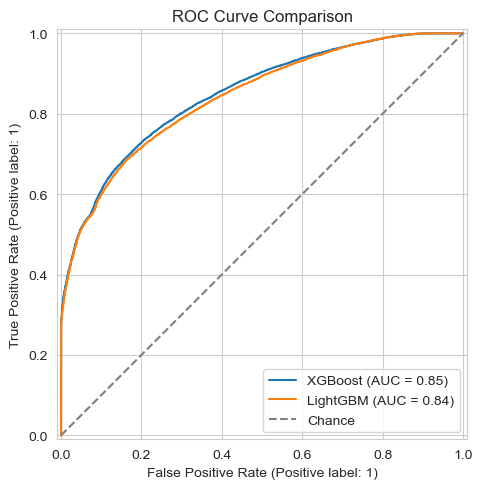

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_test, lgb_proba, name='LightGBM', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Confusion Matrix, Feature Importance & Cross-Validation (Best Model)

Best model: XGBoost
              precision    recall  f1-score   support

     On Time       0.67      0.88      0.76     16308
     Delayed       0.86      0.65      0.74     19796

    accuracy                           0.75     36104
   macro avg       0.77      0.76      0.75     36104
weighted avg       0.78      0.75      0.75     36104



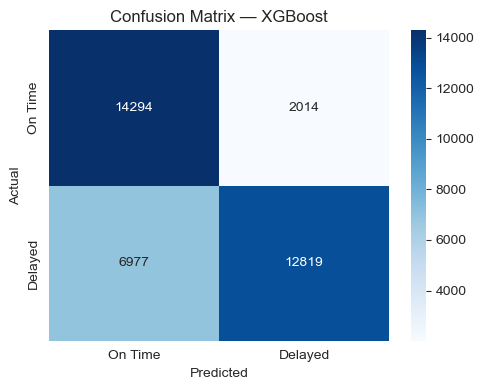

In [7]:
best_model_name = comparison['ROC-AUC'].idxmax()
best_pred = xgb_pred if best_model_name == 'XGBoost' else lgb_pred
best_model = xgb_clf if best_model_name == 'XGBoost' else lgb_clf

print(f"Best model: {best_model_name}")
print(classification_report(y_test, best_pred, target_names=['On Time', 'Delayed']))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'], yticklabels=['On Time', 'Delayed'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()


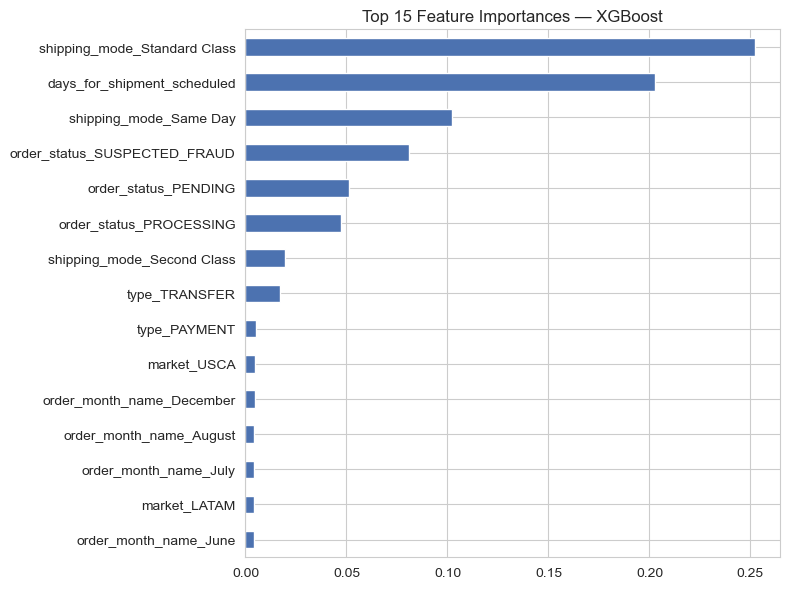

In [8]:
importances = pd.Series(best_model.feature_importances_, index=X_train_p.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = xgb_clf if best_model_name == 'XGBoost' else lgb_clf
cv_scores = cross_val_score(cv_model, X_train_p, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")


CV ROC-AUC scores: [0.8385 0.838  0.8354 0.8388 0.8382]
Mean: 0.8378  |  Std: 0.0012


## 7. Save Model

In [10]:
with open('shared_preprocessing.pkl', 'rb') as f:
    shared_artifacts = pickle.load(f)

if best_model_name == 'XGBoost':
    best_model.save_model('delay_classification_xgb.json')
else:
    joblib.dump(best_model, 'delay_classification_lgb.pkl')

classification_artifacts = dict(shared_artifacts)
classification_artifacts['best_model_name'] = best_model_name
with open('classification_preprocessing.pkl', 'wb') as f:
    pickle.dump(classification_artifacts, f)

print(f"Saved model ({best_model_name}) and preprocessing artifacts.")


Saved model (XGBoost) and preprocessing artifacts.


## Summary

- Compared XGBoost and LightGBM for predicting `late_delivery_risk`
- Selected the best model by ROC-AUC, validated with 5-fold cross-validation
- Saved the model and preprocessing pipeline for Module 4 handoff

**Next: Part 3 — Regression model for `delay_duration_days`.**
